In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.neighbors import KernelDensity 
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture

In [31]:
#upload CSV of SDSS
ra, dec, z, phot_u, phot_g, phot_r, phot_i, phot_z  = np.loadtxt('sdss_cutout.csv', unpack=True,skiprows=1, delimiter=',')
print (z)

[0.09762917 0.06773683 0.06335044 ... 0.10209855 0.06914159 0.07091606]


Task 1 

In [14]:
#cut = (d["z"] > 0.08) & (d["z"]< 0.12)

In [7]:
cut_2 = (z > 0.09) & (z < 0.1)
ra, dec, z, phot_u, phot_r = ra[cut_2], dec[cut_2], z[cut_2], phot_u[cut_2], phot_r[cut_2]

Text(0.5, 1.0, 'RA vs. DEC')

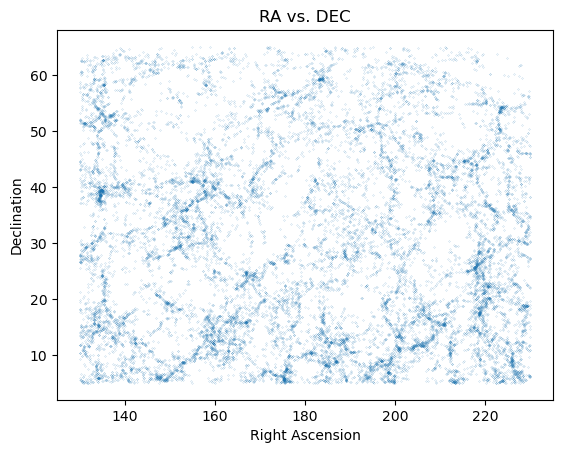

In [16]:
plt.scatter(ra, dec, s=0.01)
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

In [32]:
phot_color = phot_u - phot_r
red = phot_color>2.3
blue = phot_color<=2.3
r_red  = phot_r[red]
r_blue = phot_r[blue]

n_red, n_blue = len(r_red), len(r_blue)
print(ra,dec)

[130.08995054 130.17390864 130.08123651 ... 149.93796257 150.02359737
 149.75311132] [52.17809664 52.55776687 52.66818765 ... 46.48235774 46.26092645
 46.45411473]


Text(0.5, 1.0, 'RA vs. DEC')

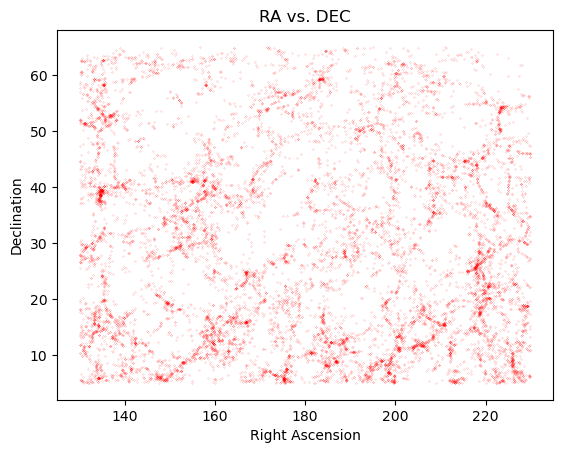

In [18]:
plt.scatter(ra[red], dec[red], s=0.01, color = 'r')
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

Text(0.5, 1.0, 'RA vs. DEC')

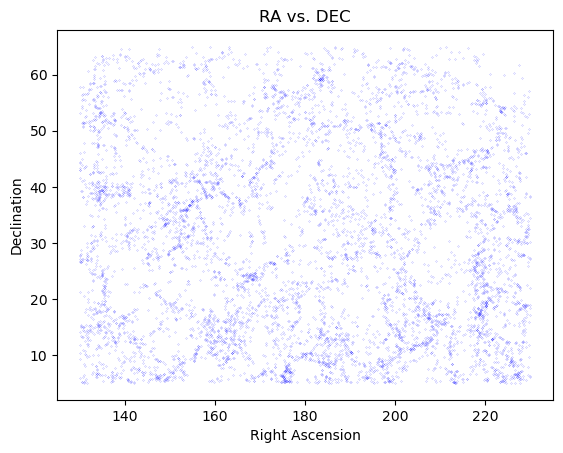

In [19]:
plt.scatter(ra[blue], dec[blue], s=0.01, color = 'b')
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

Task 2

In [ ]:
data = np.column_stack((ra, dec))
bandwidths=np.geomspace(0.05,2.0,30) 
grid=GridSearchCV(KernelDensity(kernel='gaussian'), 
                  {'bandwidth': bandwidths},cv=5, n_jobs=-1) 
grid.fit(data) #data has shape (N,2) for2D 
h_opt=grid.best_params_['bandwidth']
cv_score = grid.cv_results_['mean_test_score']

print(cv_score)

In [26]:
data = np.column_stack((ra, dec))
std_ra = np.std(ra)
std_dec = np.std(dec)
std_hat =  (std_ra**2 + std_dec**2)**(1/2)

h_sil = 1.06 * std_hat * len(data)**(-1/5)*np.pi/180

print(h_sil)

0.08792320632527752


In [65]:
colors = phot_color[:,np.newaxis]

gm_arr=[]
bic_scores=[]
models = dict()
for k in range(1,7): 
    gm=GaussianMixture(n_components=k, n_init=10).fit(colors) 
    bic_scores.append(gm.bic(colors)) 
    models[k] = gm 
    gm_arr.append(gm)
    print(bic_scores)


[577064.1629687388]
[577064.1629687388, 561811.6598977444]
[577064.1629687388, 561811.6598977444, 545908.8340992943]
[577064.1629687388, 561811.6598977444, 545908.8340992943, 545412.6917619678]
[577064.1629687388, 561811.6598977444, 545908.8340992943, 545412.6917619678, 544847.3336852393]
[577064.1629687388, 561811.6598977444, 545908.8340992943, 545412.6917619678, 544847.3336852393, 543494.6087282711]


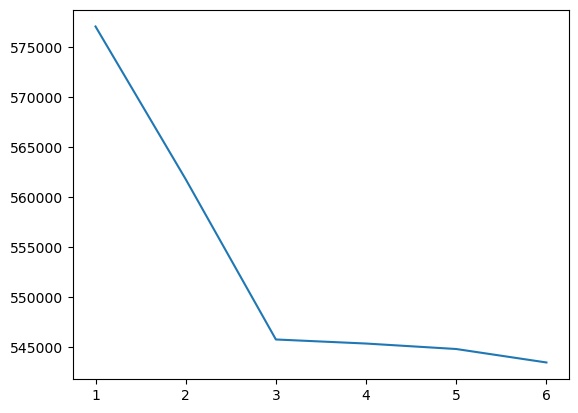

In [45]:
plt.plot(range(1,7), bic_scores)

(array([3.0000e+00, 1.0000e+00, 5.0000e+00, 2.0000e+00, 2.0000e+00,
        8.0000e+00, 5.0000e+00, 1.4000e+01, 1.8000e+01, 1.0000e+01,
        1.2000e+01, 1.7000e+01, 1.9000e+01, 3.0000e+01, 3.2000e+01,
        5.6000e+01, 1.0700e+02, 2.0500e+02, 3.6900e+02, 7.3800e+02,
        1.2610e+03, 1.8950e+03, 2.8140e+03, 3.6400e+03, 4.5410e+03,
        5.3980e+03, 6.1130e+03, 6.8090e+03, 7.2820e+03, 7.5970e+03,
        7.6920e+03, 8.0630e+03, 7.9620e+03, 8.0980e+03, 7.9650e+03,
        7.6410e+03, 7.6940e+03, 7.5010e+03, 7.7900e+03, 8.0870e+03,
        8.5600e+03, 9.2330e+03, 1.0293e+04, 1.1762e+04, 1.3422e+04,
        1.4874e+04, 1.5919e+04, 1.5809e+04, 1.5230e+04, 1.3620e+04,
        1.2018e+04, 9.9970e+03, 8.2310e+03, 6.6470e+03, 5.4980e+03,
        4.2700e+03, 3.5180e+03, 2.7150e+03, 2.2220e+03, 1.6520e+03,
        1.3480e+03, 1.0330e+03, 7.6400e+02, 6.0600e+02, 4.9100e+02,
        3.7400e+02, 3.7100e+02, 2.6800e+02, 2.3000e+02, 2.0500e+02,
        1.6900e+02, 1.4300e+02, 1.0500e+02, 9.10

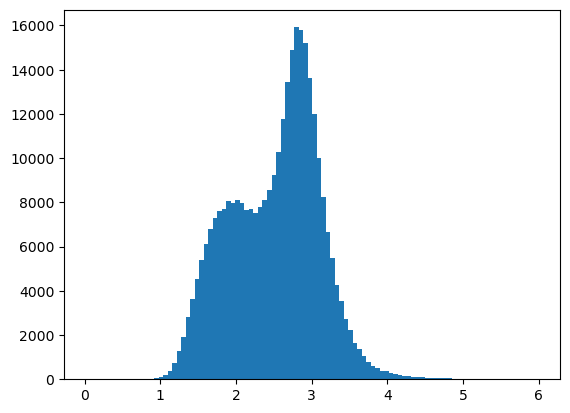

In [56]:
plt.hist(colors, bins=100)

In [61]:
delta_bic = []
for k in range(1,6):
    delta_bic.append(bic_scores[k-1]-bic_scores[k])
    print (delta_bic)


[15261.96769925952]
[15261.96769925952, 16009.904345260235]
[15261.96769925952, 16009.904345260235, 405.91206115169916]
[15261.96769925952, 16009.904345260235, 405.91206115169916, 547.0126129541313]
[15261.96769925952, 16009.904345260235, 405.91206115169916, 547.0126129541313, 1345.1436688208487]


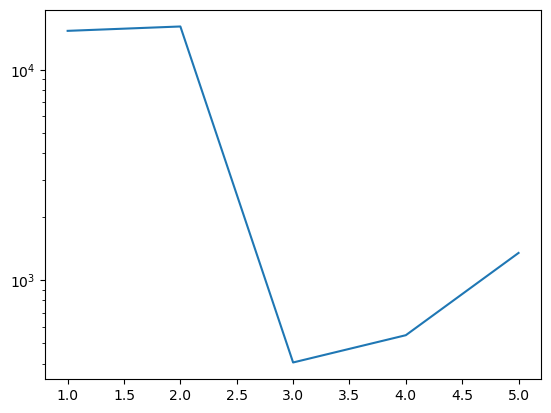

In [62]:
plt.plot(range(1,6), delta_bic)
plt.yscale('log')

In [74]:
tau = gm_arr[2].predict_proba(colors)
print (tau)

[[2.11642758e-01 1.00252290e-01 6.88104952e-01]
 [1.89681745e-01 1.29301644e-02 7.97388091e-01]
 [7.24613397e-02 9.09662573e-01 1.78760874e-02]
 ...
 [2.01383133e-01 4.35899693e-03 7.94257870e-01]
 [2.16309064e-02 9.78260546e-01 1.08547409e-04]
 [3.08056421e-02 9.68352322e-01 8.42035503e-04]]


In [102]:
print(gm_arr[2].converged_)

True


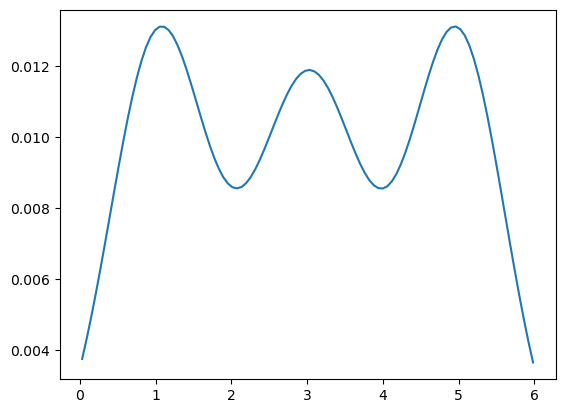

In [97]:
x= np.linspace(colors.min(), colors.max(), 100).reshape(-1, 1)
log_probs = gm_arr[2].score_samples(x)
sum_of_scores = (np.exp(log_probs)).sum()
probs = np.exp(log_probs) / sum_of_scores
plt.plot(x, probs)

(array([1.57427247e-04, 5.24757489e-05, 2.62378744e-04, 1.04951498e-04,
        1.04951498e-04, 4.19805991e-04, 2.62378744e-04, 7.34660484e-04,
        9.44563479e-04, 5.24757489e-04, 6.29708986e-04, 8.92087730e-04,
        9.97039228e-04, 1.57427247e-03, 1.67922396e-03, 2.93864194e-03,
        5.61490513e-03, 1.07575285e-02, 1.93635513e-02, 3.87271027e-02,
        6.61719193e-02, 9.94415441e-02, 1.47666757e-01, 1.91011726e-01,
        2.38292376e-01, 2.83264092e-01, 3.20784253e-01, 3.57307374e-01,
        3.82128403e-01, 3.98658264e-01, 4.03643460e-01, 4.23111963e-01,
        4.17811912e-01, 4.24948614e-01, 4.17969340e-01, 4.00967197e-01,
        4.03748412e-01, 3.93620592e-01, 4.08786084e-01, 4.24371381e-01,
        4.49192410e-01, 4.84508589e-01, 5.40132883e-01, 6.17219758e-01,
        7.04329501e-01, 7.80524288e-01, 8.35361446e-01, 8.29589114e-01,
        7.99205655e-01, 7.14719699e-01, 6.30653550e-01, 5.24600061e-01,
        4.31927889e-01, 3.48806303e-01, 2.88511667e-01, 2.240714

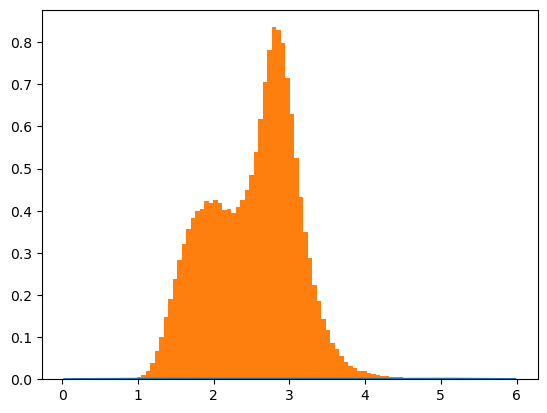

In [92]:
x= np.linspace(colors.min(), colors.max(), 1000).reshape(-1, 1)
log_probs = gm_arr[2].score_samples(x)
sum_of_scores = (np.exp(log_probs)).sum()
probs = np.exp(log_probs) / sum_of_scores

plt.plot(x, probs)
plt.hist(colors, density=True, bins=100)